**Write the names of all group members (max. 5 members)**:
- Martin Rodriguez
- Benedict Armstrong
- Lluis Marill
- Oscar Balcells

When submitting your work, please follow closely the template below.

# Exercise 1 (Poisson GLM)

### Exercise 1 (a)
First, we'll load and preprocess the data according to the task requirements.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PoissonRegressor

np.random.seed(42)

In [57]:
# Read csv file `freMTPL2freq.csv` (e.g. use pandas)
data = pd.read_csv("freMTPL2freq.csv", sep=";", decimal=",")

In [58]:
print("\nDescriptive Statistics:")
print(data.describe())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nData Types:")
print(data.dtypes)

print("\nUnique Values per Column:")
for col in data.columns:
    print(f"\n{col}: {data[col].nunique()} unique values")
    if data[col].dtype != 'float64' and data[col].nunique() < 20:
        print(data[col].value_counts())


Descriptive Statistics:
            VehPower         VehAge        DrivAge     BonusMalus  \
count  678007.000000  678007.000000  678007.000000  678007.000000   
mean        6.454653       7.044218      45.499061      59.761588   
std         2.050902       5.666235      14.137492      15.636700   
min         4.000000       0.000000      18.000000      50.000000   
25%         5.000000       2.000000      34.000000      50.000000   
50%         6.000000       6.000000      44.000000      50.000000   
75%         7.000000      11.000000      55.000000      64.000000   
max        15.000000     100.000000     100.000000     230.000000   

             Density       Exposure        ClaimNb  
count  678007.000000  678007.000000  678007.000000  
mean     1792.430975       0.528547       0.038913  
std      3958.663031       0.364081       0.204752  
min         1.000000       0.002732       0.000000  
25%        92.000000       0.180000       0.000000  
50%       393.000000       0.490000

In [59]:
# Apply required feature transformations
processed_data = data.copy()
processed_data["VehPower"] = np.log(data["VehPower"])
processed_data["VehAge"] = pd.cut(data["VehAge"], 
                                 bins=[-np.inf, 6, 13, np.inf],
                                 labels=[0, 1, 2])
processed_data["DrivAge"] = np.log(data["DrivAge"])
processed_data["BonusMalus"] = np.log(data["BonusMalus"])
processed_data["Density"] = np.log(data["Density"])

# Display first few rows to verify transformations
processed_data.head()

,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,Exposure,ClaimNb
0,1.386294,1,3.135494,4.605170,B6,Regular,8.972971,R31,0.76,0
1,1.386294,0,3.258097,4.605170,B6,Regular,7.744137,R31,0.74,0
2,1.386294,0,3.258097,4.605170,B6,Regular,7.744137,R31,0.11,0
3,1.945910,0,3.784190,3.912023,B6,Regular,3.610918,R94,0.83,0
4,1.609438,0,3.367296,4.499810,B6,Regular,5.814131,R91,0.69,0


Let's visualize the distribution of our transformed features:

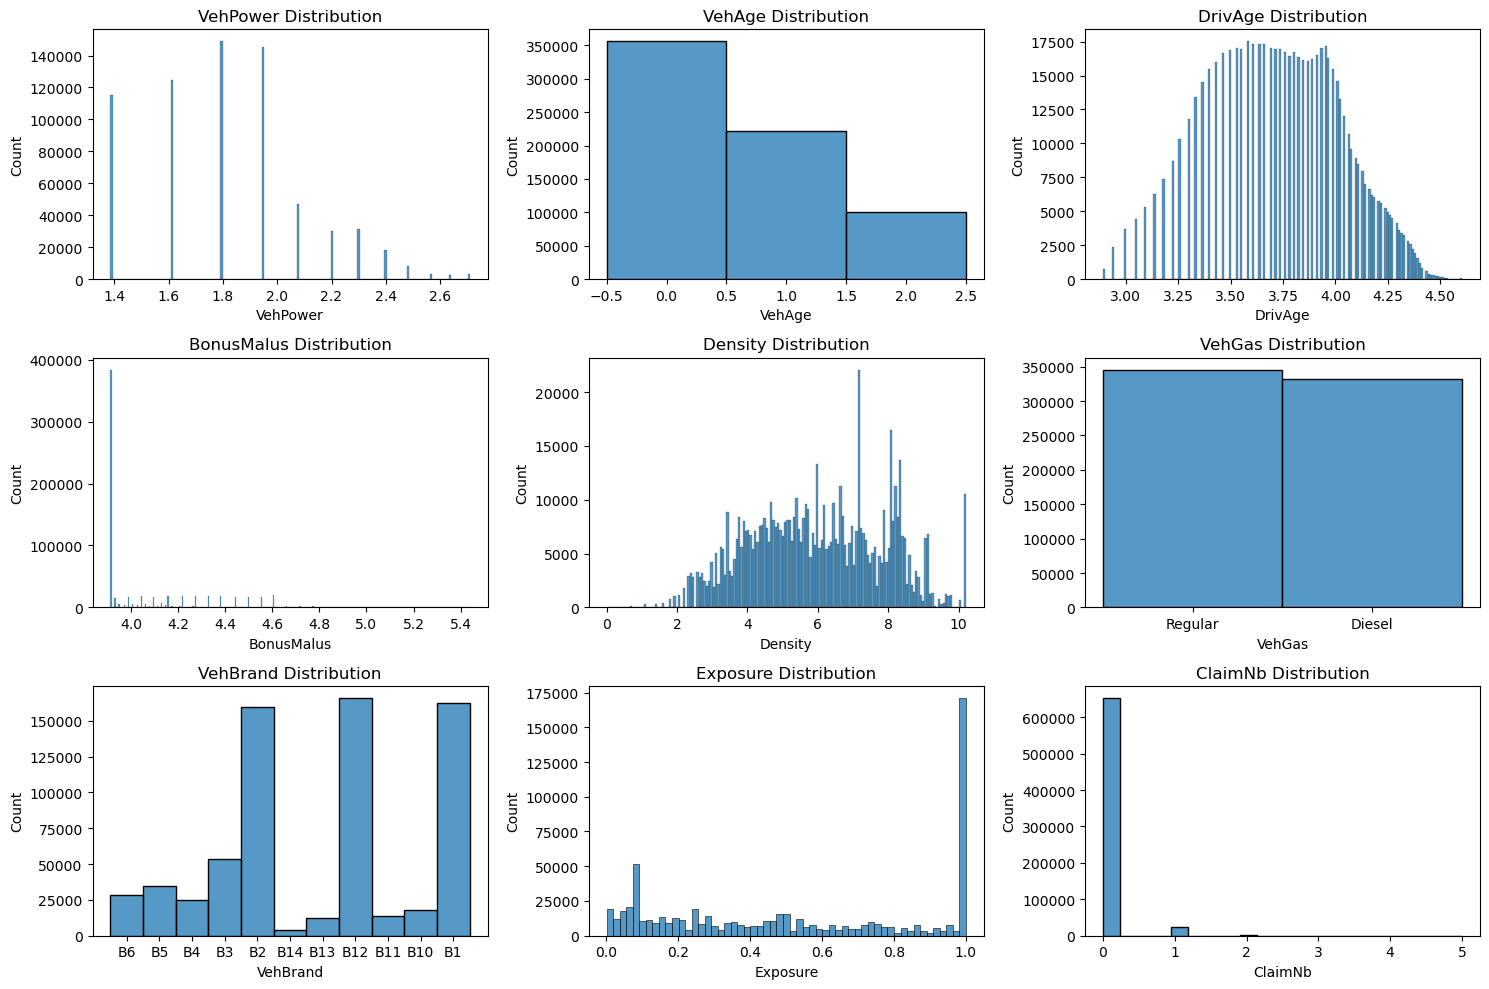

In [62]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
features = ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'VehGas', 'VehBrand', 'Exposure', 'ClaimNb']
for i, feature in enumerate(features):
    row = i // 3
    col = i % 3
    sns.histplot(data=processed_data, x=feature, ax=axes[row, col])
    axes[row, col].set_title(f'{feature} Distribution')
plt.tight_layout()
plt.show()

/Users/oscarbalcells/anaconda3/envs/arena/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


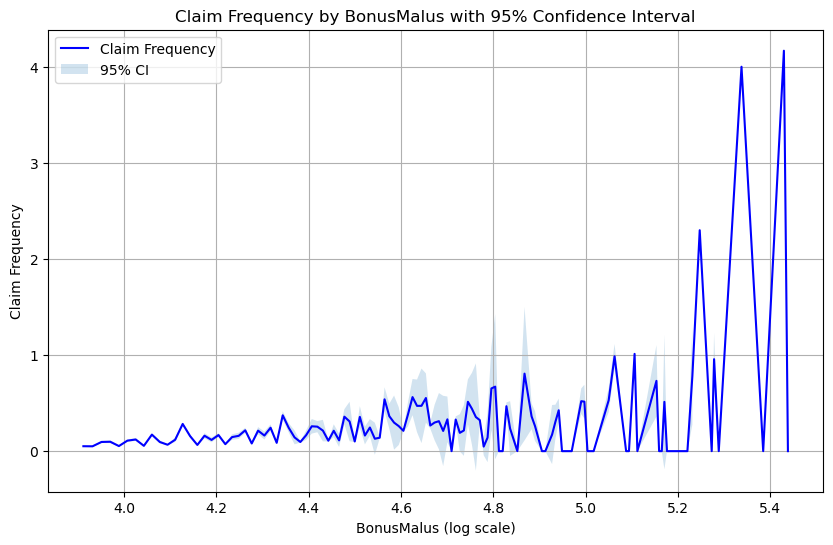

In [88]:
# Calculate claim frequency and confidence intervals by BonusMalus groups
bonusmalus_groups = pd.DataFrame({
    'BonusMalus': processed_data['BonusMalus'],
    'ClaimNb': processed_data['ClaimNb'],
    'Exposure': processed_data['Exposure']
})

# Group and calculate statistics
grouped_stats = bonusmalus_groups.groupby('BonusMalus').agg({
    'ClaimNb': 'sum',
    'Exposure': 'sum'
}).reset_index()

grouped_stats['claim_freq'] = grouped_stats['ClaimNb'] / grouped_stats['Exposure']

# Calculate 95% confidence intervals
z_score = 1.96  # For 95% confidence interval
grouped_stats['ci'] = z_score * np.sqrt(
    (grouped_stats['claim_freq'] * (1 - grouped_stats['claim_freq'])) / 
    grouped_stats['Exposure']
)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(grouped_stats['BonusMalus'], grouped_stats['claim_freq'], 'b-', label='Claim Frequency')
plt.fill_between(
    grouped_stats['BonusMalus'],
    grouped_stats['claim_freq'] - grouped_stats['ci'],
    grouped_stats['claim_freq'] + grouped_stats['ci'],
    alpha=0.2,
    label='95% CI'
)

plt.xlabel('BonusMalus (log scale)')
plt.ylabel('Claim Frequency')
plt.title('Claim Frequency by BonusMalus with 95% Confidence Interval')
plt.legend()
plt.grid(True)
plt.show()


### Exercise 1 (b)

In [37]:
# One-hot encode categorical variables
categorical_cols = ["VehAge", "VehBrand", "VehGas", "Region"]
processed_data = pd.get_dummies(processed_data, columns=categorical_cols)

# Split into train and test sets (90-10 split)
train_data, test_data = train_test_split(processed_data, test_size=0.1, random_state=42)

# Prepare features and targets
def prepare_data(data):
    exposure = np.array(data["Exposure"], dtype=np.float64)
    y = np.array(data["ClaimNb"]) / exposure
    X = np.array(data.drop(["Exposure", "ClaimNb"], axis=1), dtype=np.float64)
    return X, y, exposure

X_train, y_train, train_exposure = prepare_data(train_data)
X_test, y_test, test_exposure = prepare_data(test_data)

# Standardize features
train_mean = np.mean(X_train, axis=0)
train_std = np.std(X_train, axis=0)
X_train_norm = (X_train - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

In [77]:
# Print basic statistics about the target variable distribution
print("\nTarget Variable Statistics:")
print(f"Mean: {np.mean(y_train):.4f}")
print(f"Median: {np.median(y_train):.4f}")
print(f"Std Dev: {np.std(y_train):.4f}")
print(f"Min: {np.min(y_train):.4f}")
print(f"Max: {np.max(y_train):.4f}")
print(f"% Zero Values: {(y_train == 0).mean() * 100:.2f}%")
print(f"% Non-Zero Values: {(y_train > 0).mean() * 100:.2f}%")

# Print percentiles
print("\nPercentiles:")
percentiles = [1, 5, 25, 50, 75, 95, 99]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(y_train, p):.4f}")


Target Variable Statistics:
Mean: 0.1167
Median: 0.0000
Std Dev: 1.9642
Min: 0.0000
Max: 365.0000
% Zero Values: 96.31%
% Non-Zero Values: 3.69%

Percentiles:
1th percentile: 0.0000
5th percentile: 0.0000
25th percentile: 0.0000
50th percentile: 0.0000
75th percentile: 0.0000
95th percentile: 0.0000
99th percentile: 2.2727


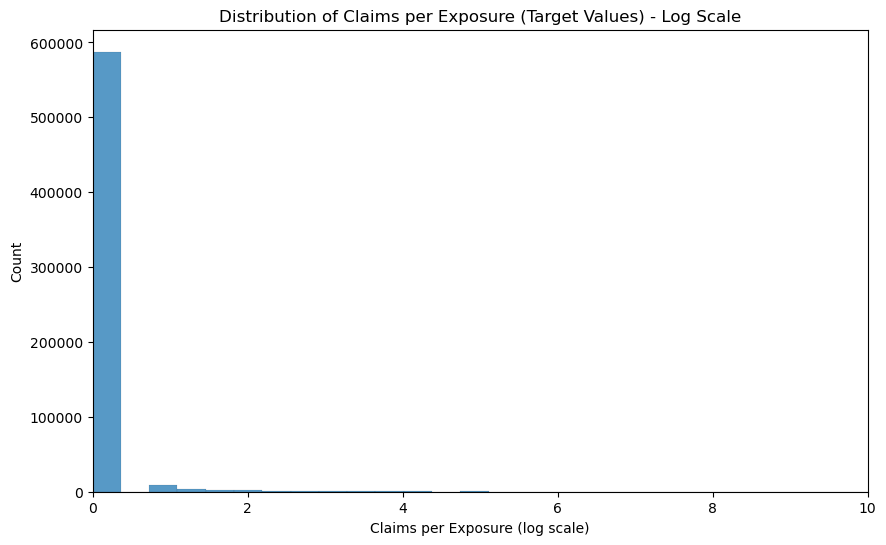

In [75]:
# Plot the distribution of target values (claims per exposure) on log scale
plt.figure(figsize=(10, 6))
sns.histplot(data=y_train, bins=1000, log_scale=False)
plt.xlim(0, 10)
plt.title('Distribution of Claims per Exposure (Target Values) - Log Scale')
plt.xlabel('Claims per Exposure (log scale)')
plt.ylabel('Count')
plt.show()


The target values are almost all zero and are sometimes extremely large in relative terms (max is 365 whereas mean is ~0.11).

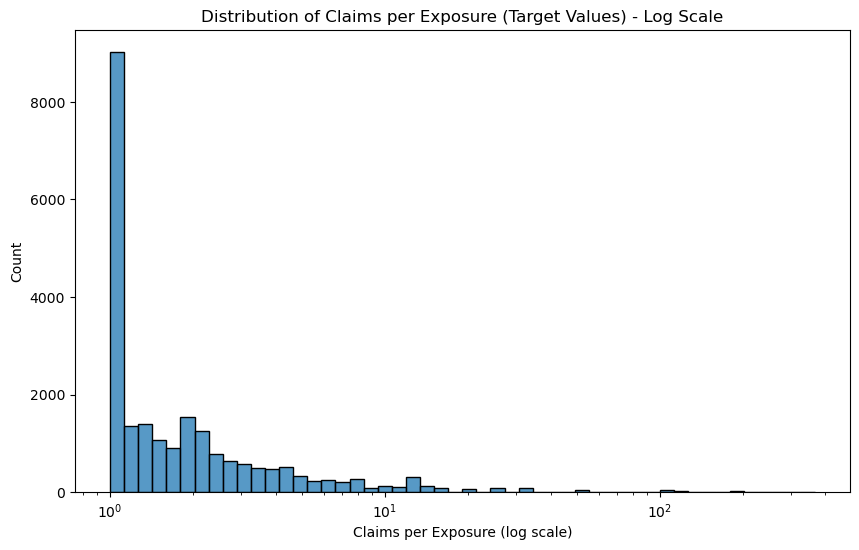

In [72]:
# Plot the distribution of target values (claims per exposure) on log scale
plt.figure(figsize=(10, 6))
sns.histplot(data=y_train, bins=50, log_scale=True)
plt.title('Distribution of Claims per Exposure (Target Values) - Log Scale')
plt.xlabel('Claims per Exposure (log scale)')
plt.ylabel('Count')
plt.show()


In [38]:
def poisson_deviance(y_true, y_pred, exposure):
    """Calculate the Poisson deviance loss"""
    mask = y_true > 0
    deviance = np.zeros_like(y_true)
    
    # Where y_true > 0
    deviance[mask] = 2 * exposure[mask] * (
        y_pred[mask] - y_true[mask] - 
        y_true[mask] * np.log(y_pred[mask]) + 
        y_true[mask] * np.log(y_true[mask])
    )
    
    # Where y_true == 0
    deviance[~mask] = 2 * exposure[~mask] * y_pred[~mask]
    
    return np.sum(deviance) / np.sum(exposure)

In [42]:
glm = PoissonRegressor(alpha=0, max_iter=300)
glm.fit(X_train_norm, y_train, sample_weight=train_exposure)

# Make predictions
train_pred = glm.predict(X_train_norm)
test_pred = glm.predict(X_test_norm)

# Calculate metrics
metrics = {
    'Train': {
        'MAE': np.mean(np.abs(train_pred - y_train)),
        'MSE': np.mean((train_pred - y_train) ** 2),
        'Poisson Deviance (Loss)': poisson_deviance(y_train, train_pred, train_exposure)
    },
    'Test': {
        'MAE': np.mean(np.abs(test_pred - y_test)),
        'MSE': np.mean((test_pred - y_test) ** 2),
        'Poisson Deviance (Loss)': poisson_deviance(y_test, test_pred, test_exposure)
    }
}

# Display results
pd.DataFrame(metrics).round(4)

,Train,Test
MAE,0.1882,0.2005
MSE,3.8567,5.3898
Poisson Deviance (Loss),0.4579,0.4492


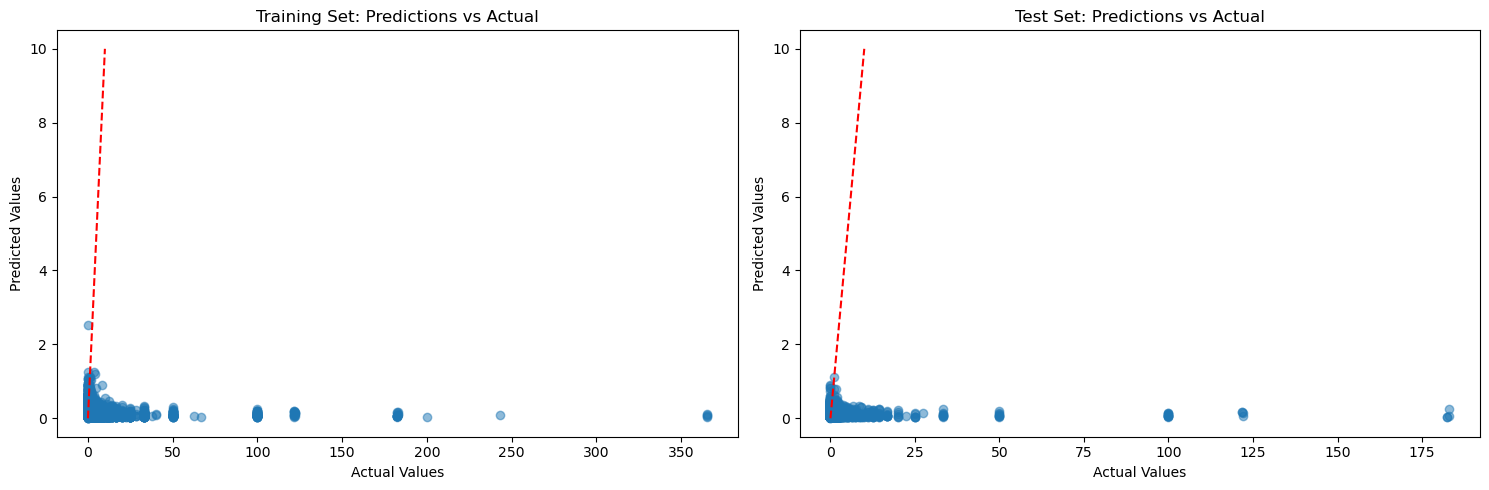

In [103]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Training set predictions
ax1.scatter(y_train, train_pred, alpha=0.5)
ax1.plot([0, 10], [0, 10], 'r--')
ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')
ax1.set_title('Training Set: Predictions vs Actual')

# Test set predictions
ax2.scatter(y_test, test_pred, alpha=0.5)
ax2.plot([0, 10], [0, 10], 'r--')
ax2.set_xlabel('Actual Values')
ax2.set_ylabel('Predicted Values')
ax2.set_title('Test Set: Predictions vs Actual')

plt.tight_layout()
plt.show()

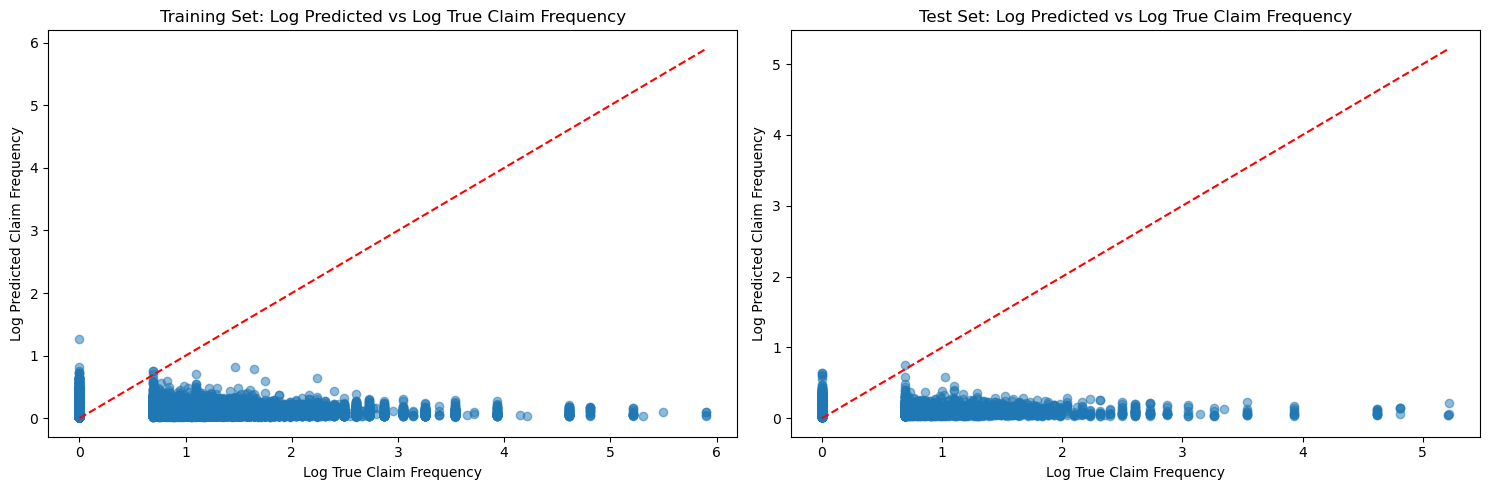

In [101]:
# Plot true vs predicted claim frequency on log scale for train and test sets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Add a constant to shift the data away from 0
C = 1

# Training set
train_freq_true = y_train
train_freq_pred = train_pred
log_train_true = np.log(train_freq_true + C)
log_train_pred = np.log(train_freq_pred + C)

ax1.scatter(log_train_true, log_train_pred, alpha=0.5)
min_val = min(log_train_true.min(), log_train_pred.min())
max_val = max(log_train_true.max(), log_train_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--')
ax1.set_xlabel('Log True Claim Frequency')
ax1.set_ylabel('Log Predicted Claim Frequency')
ax1.set_title('Training Set: Log Predicted vs Log True Claim Frequency')

# Test set
test_freq_true = y_test
test_freq_pred = test_pred
log_test_true = np.log(test_freq_true + C)
log_test_pred = np.log(test_freq_pred + C)

ax2.scatter(log_test_true, log_test_pred, alpha=0.5)
min_val = min(log_test_true.min(), log_test_pred.min())
max_val = max(log_test_true.max(), log_test_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--')
ax2.set_xlabel('Log True Claim Frequency')
ax2.set_ylabel('Log Predicted Claim Frequency')
ax2.set_title('Test Set: Log Predicted vs Log True Claim Frequency')

plt.tight_layout()
plt.show()


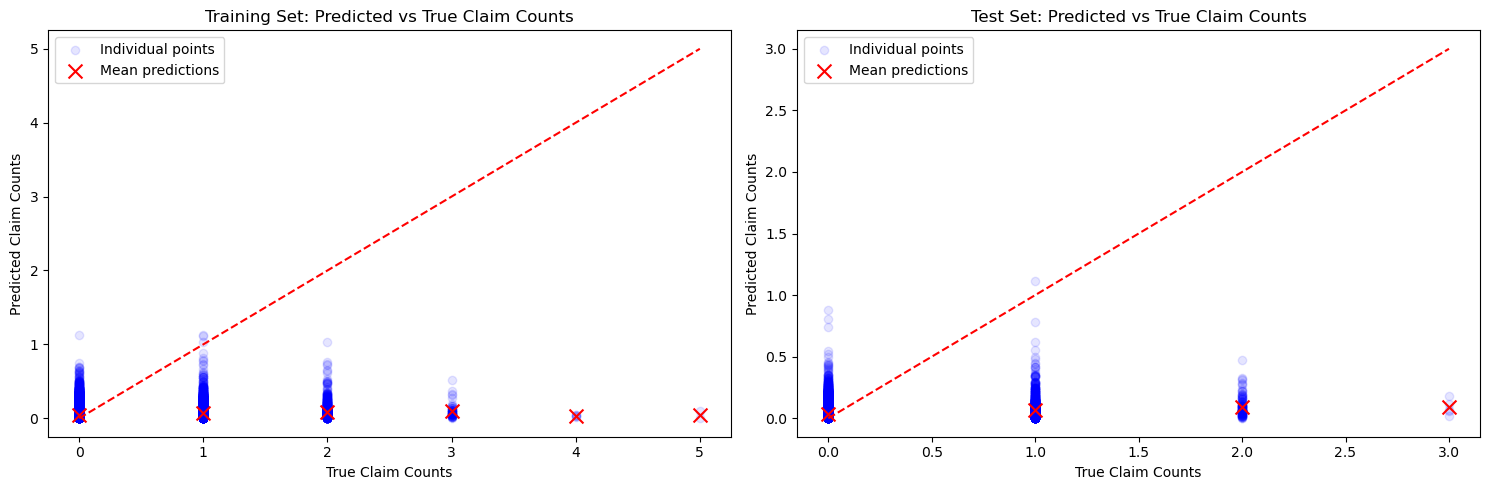

In [113]:
nb_claims_values = np.arange(6)

# Plot true vs predicted claim counts (frequency * exposure)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Training set
train_counts_true = y_train * train_exposure
train_counts_pred = train_pred * train_exposure

# Calculate mean predictions for each true value
train_means = {}
for true_val in nb_claims_values:  # 0 to 5
    mask = (train_counts_true == true_val)
    if mask.any():
        mean_pred = train_counts_pred[mask].mean()
        train_means[true_val] = mean_pred

# Plot individual points with low alpha
ax1.scatter(train_counts_true, train_counts_pred, alpha=0.1, color='blue', label='Individual points')
# Plot means as crosses
ax1.scatter(list(train_means.keys()), list(train_means.values()), color='red', s=100, marker='x', label='Mean predictions')

min_val = min(train_counts_true.min(), train_counts_pred.min())
max_val = max(train_counts_true.max(), train_counts_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--')
ax1.set_xlabel('True Claim Counts')
ax1.set_ylabel('Predicted Claim Counts')
ax1.set_title('Training Set: Predicted vs True Claim Counts')
ax1.legend()

# Test set
test_counts_true = y_test * test_exposure
test_counts_pred = test_pred * test_exposure

# Calculate mean predictions for each true value
test_means = {}
for true_val in nb_claims_values:  # 0 to 5
    mask = (test_counts_true == true_val)
    if mask.any():
        mean_pred = test_counts_pred[mask].mean()
        test_means[true_val] = mean_pred

# Plot individual points with low alpha
ax2.scatter(test_counts_true, test_counts_pred, alpha=0.1, color='blue', label='Individual points')
# Plot means as crosses
ax2.scatter(list(test_means.keys()), list(test_means.values()), color='red', s=100, marker='x', label='Mean predictions')

min_val = min(test_counts_true.min(), test_counts_pred.min())
max_val = max(test_counts_true.max(), test_counts_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--')
ax2.set_xlabel('True Claim Counts')
ax2.set_ylabel('Predicted Claim Counts')
ax2.set_title('Test Set: Predicted vs True Claim Counts')
ax2.legend()

plt.tight_layout()
plt.show()

# Exercise 2: Poisson feedforward neural network model

In [120]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import tqdm
from sklearn.model_selection import KFold

### Exercise 2 (a)

In [149]:
class InsuranceDataset(Dataset):
    def __init__(self, X, y, exposure):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.exposure = torch.FloatTensor(exposure)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.exposure[idx]

class PoissonNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32], dropout_rate=0.2, l2_lambda=0.01):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        # Build hidden layers dynamically based on hidden_dims
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
            
        # Output layer
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
        self.l2_lambda = l2_lambda
        
    def forward(self, x):
        return torch.exp(self.network(x))

### Exercise 2 (b)

Now we'll train the neural network and compare its performance with the GLM.

In [153]:
def poisson_deviance_loss_fn(output, target, exposure):
    mask = target > 0
    loss = torch.zeros_like(target)
    loss[mask] = 2 * exposure[mask] * (output[mask] - target[mask] - target[mask] * torch.log(output[mask]) + target[mask] * torch.log(target[mask]))
    loss[~mask] = 2 * exposure[~mask] * output[~mask]
    total_exposure = torch.sum(exposure)
    return torch.sum(loss) / total_exposure

In [150]:
# Training loop
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch, exposure_batch in loader:
            batch_size = X_batch.shape[0]
            pred = model(X_batch).squeeze()
            loss = poisson_deviance_loss_fn(pred, y_batch, exposure_batch)
            total_loss += loss.item() * batch_size
    return total_loss / len(loader.dataset)

def train_epoch(model, loader, optimizer):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch, exposure_batch in loader:
        batch_size = X_batch.shape[0]
        optimizer.zero_grad()
        pred = model(X_batch).squeeze()
        loss = poisson_deviance_loss_fn(pred, y_batch, exposure_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_size
    return epoch_loss / len(loader.dataset)

In [160]:
# Define hyperparameter grid for neural network
hidden_layers = [
    [64],
    [64, 32],
    [128, 64],
]
learning_rates = [0.001, 0.01]
weight_decays = [0.0001, 0.001, 0.01]

# Initialize k-fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store results
cv_results = []

# Perform grid search with cross validation
for hidden in hidden_layers:
    for lr in learning_rates:
        for wd in weight_decays:
            fold_scores = []

            for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_norm)):
                # Split data for this fold
                X_fold_train = torch.FloatTensor(X_train_norm[train_idx])
                y_fold_train = torch.FloatTensor(y_train[train_idx])
                X_fold_val = torch.FloatTensor(X_train_norm[val_idx])
                y_fold_val = torch.FloatTensor(y_train[val_idx])
                exposure_fold_train = torch.FloatTensor(train_exposure[train_idx])
                exposure_fold_val = torch.FloatTensor(train_exposure[val_idx])

                # Create and train model
                fold_model = PoissonNN(
                    input_dim=X_fold_train.shape[1],
                    hidden_dims=hidden,
                    l2_lambda=wd
                )
                optimizer = torch.optim.Adam(
                    fold_model.parameters(),
                    lr=lr,
                    weight_decay=wd
                )

                # Train for 10 epochs
                for epoch in range(10):
                    fold_model.train()
                    optimizer.zero_grad()
                    output = fold_model(X_fold_train).squeeze()
                    loss = poisson_deviance_loss_fn(output, y_fold_train, exposure_fold_train)
                    loss.backward()
                    optimizer.step()

                # Evaluate on validation set
                fold_model.eval()
                with torch.no_grad():
                    val_pred = fold_model(X_fold_val).squeeze()
                    val_score = poisson_deviance_loss_fn(val_pred, y_fold_val, exposure_fold_val)
                fold_scores.append(val_score.item())

            # Store average score across folds
            mean_score = np.mean(fold_scores)
            cv_results.append({
                'hidden_layers': hidden,
                'learning_rate': lr,
                'weight_decay': wd,
                'mean_val_score': mean_score
            })
            print(f"Hidden: {hidden}, LR: {lr}, WD: {wd}, Score: {mean_score:.4f}")

# Find best hyperparameters
best_result = min(cv_results, key=lambda x: x['mean_val_score'])
print("\nBest hyperparameters:")
print(f"Hidden layers: {best_result['hidden_layers']}")
print(f"Learning rate: {best_result['learning_rate']}")
print(f"Weight decay: {best_result['weight_decay']}")
print(f"Validation score: {best_result['mean_val_score']:.4f}")

Hidden: [64], LR: 0.001, WD: 0.0001, Score: 1.0252
Hidden: [64], LR: 0.001, WD: 0.001, Score: 1.1134
Hidden: [64], LR: 0.001, WD: 0.01, Score: 0.9070
Hidden: [64], LR: 0.01, WD: 0.0001, Score: 0.6898
Hidden: [64], LR: 0.01, WD: 0.001, Score: 0.7640
Hidden: [64], LR: 0.01, WD: 0.01, Score: 0.7758
Hidden: [64, 32], LR: 0.001, WD: 0.0001, Score: 0.9514
Hidden: [64, 32], LR: 0.001, WD: 0.001, Score: 0.9934
Hidden: [64, 32], LR: 0.001, WD: 0.01, Score: 1.0200
Hidden: [64, 32], LR: 0.01, WD: 0.0001, Score: 0.7958
Hidden: [64, 32], LR: 0.01, WD: 0.001, Score: 0.7572
Hidden: [64, 32], LR: 0.01, WD: 0.01, Score: 0.8412
Hidden: [128, 64], LR: 0.001, WD: 0.0001, Score: 1.0337
Hidden: [128, 64], LR: 0.001, WD: 0.001, Score: 0.9115
Hidden: [128, 64], LR: 0.001, WD: 0.01, Score: 1.0314
Hidden: [128, 64], LR: 0.01, WD: 0.0001, Score: 0.8067
Hidden: [128, 64], LR: 0.01, WD: 0.001, Score: 0.7299
Hidden: [128, 64], LR: 0.01, WD: 0.01, Score: 0.7522

Best hyperparameters:
Hidden layers: [64]
Learning rat

In [161]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Hyperparameters
batch_size = 10_000
n_epochs = 50
lr = 0.01
hidden_dims = [64]
l2_lambda = 0.0001  # Set non-zero L2 regularization

# Create data loaders
train_dataset = InsuranceDataset(X_train_norm, y_train, train_exposure)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = InsuranceDataset(X_test_norm, y_test, test_exposure)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# Initialize model and optimizer
model = PoissonNN(input_dim=X_train_norm.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2_lambda)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)

Training NN: 100%|██████████| 50/50 [04:32<00:00,  5.46s/it, train_loss=0.240, val_loss=0.233]


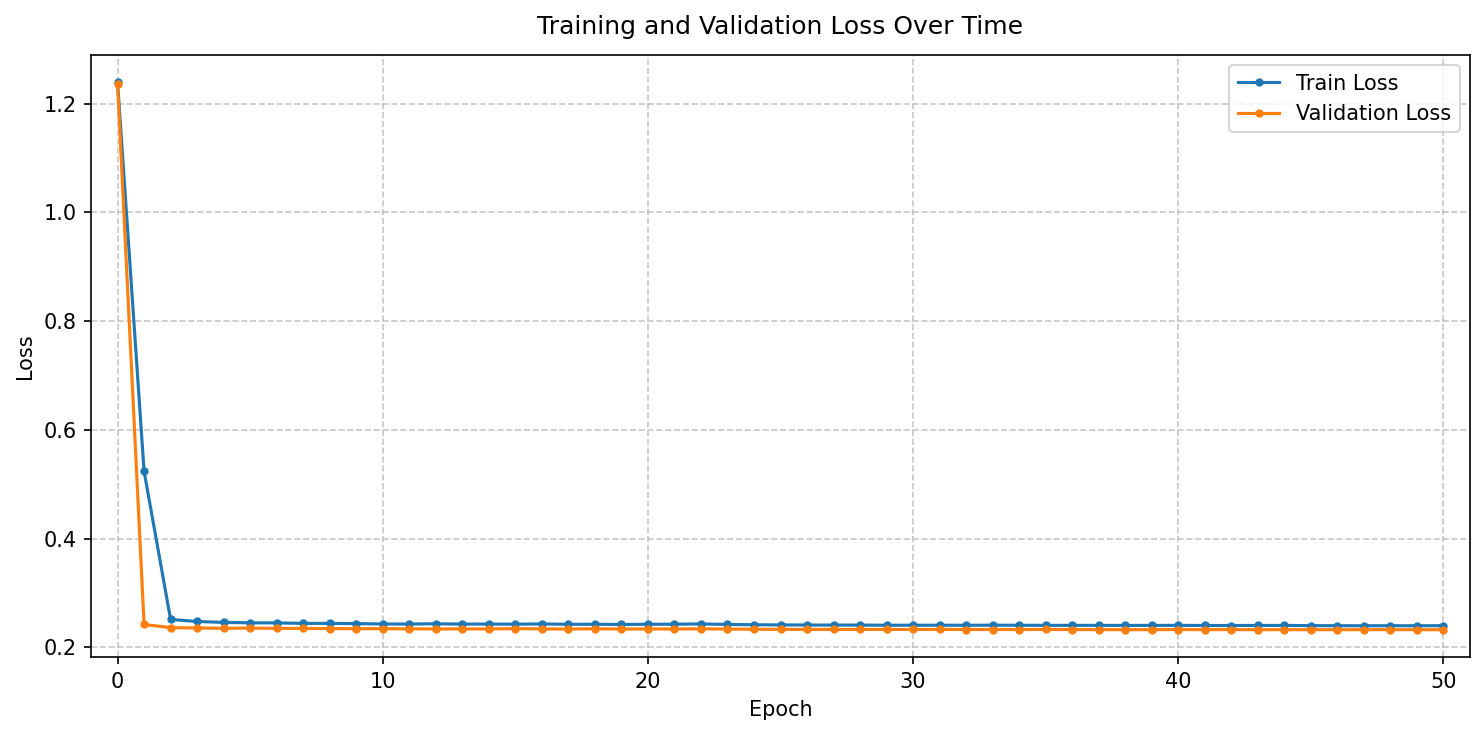

,MAE,MSE,Poisson Deviance
GLM Train,0.1882,3.8567,0.4579
GLM Test,0.2005,5.3898,0.4492
NN Train,0.1858,3.8552,0.4490
NN Test,0.1983,5.3877,0.4418


In [162]:
# Train the model
train_losses = []
val_losses = []

initial_train_loss = evaluate(model, train_loader)
initial_val_loss = evaluate(model, val_loader)

train_losses.append(initial_train_loss)
val_losses.append(initial_val_loss)

pbar = tqdm.trange(n_epochs, desc="Training NN")
pbar.set_postfix({'train_loss': f'{initial_train_loss:.3f}', 'val_loss': f'{initial_val_loss:.3f}'})

for epoch in pbar:
    train_loss = train_epoch(model, train_loader, optimizer)
    val_loss = evaluate(model, val_loader)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    pbar.set_postfix({'train_loss': f'{train_loss:.3f}', 'val_loss': f'{val_loss:.3f}'})

# Plot training and validation loss with greater precision
plt.figure(figsize=(10, 5), dpi=150)
plt.plot(train_losses, label='Train Loss', linewidth=1.5, marker='o', markersize=3)
plt.plot(val_losses, label='Validation Loss', linewidth=1.5, marker='o', markersize=3)
plt.title('Training and Validation Loss Over Time', fontsize=12, pad=10)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.margins(x=0.02)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.tight_layout()
plt.show()

# Evaluate model
model.eval()
with torch.no_grad():
    train_pred_nn = model(torch.FloatTensor(X_train_norm)).numpy().squeeze()
    test_pred_nn = model(torch.FloatTensor(X_test_norm)).numpy().squeeze()

# Calculate metrics
metrics_nn = {
    'MAE': {
        'GLM Train': np.mean(np.abs(train_pred - y_train)),
        'GLM Test': np.mean(np.abs(test_pred - y_test)),
        'NN Train': np.mean(np.abs(train_pred_nn - y_train)),
        'NN Test': np.mean(np.abs(test_pred_nn - y_test))
    },
    'MSE': {
        'GLM Train': np.mean((train_pred - y_train) ** 2),
        'GLM Test': np.mean((test_pred - y_test) ** 2), 
        'NN Train': np.mean((train_pred_nn - y_train) ** 2),
        'NN Test': np.mean((test_pred_nn - y_test) ** 2)
    },
    'Poisson Deviance': {
        'GLM Train': poisson_deviance(y_train, train_pred, train_exposure),
        'GLM Test': poisson_deviance(y_test, test_pred, test_exposure),
        'NN Train': poisson_deviance(y_train, train_pred_nn, train_exposure),
        'NN Test': poisson_deviance(y_test, test_pred_nn, test_exposure)
    }
}

# Create DataFrame with metrics
results_comparison = pd.DataFrame(metrics_nn).round(4)
results_comparison

# Exercise 3: Tree-based methods

### Exercise 3 (a)

In [23]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

In [37]:
def loss(output, target):
    if target > 0:
        return 2 * (output - target - target * np.log(output) + target * np.log(target))
    return 2 * output

In [25]:
def poiss_dev(exp, output, target):
    sum = 0
    for e, o, t in zip(exp, output, target):
        sum += e * loss(o, t)
    return sum / np.sum(exp)

In [26]:
def eval_model_performance(model, X, Y, exposure) -> dict:
    y_pred = model.predict(X)
    return {
        "MAE": np.mean(np.abs(y_pred - Y)),
        "MSE": np.mean((y_pred - Y) ** 2),
        "poiss_dev": poiss_dev(exposure, y_pred, Y),
    }

In [27]:
def cross_validate_model(model, X, Y, exposure, n_splits=5):
    kf = KFold(n_splits=n_splits)
    results = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        Y_train, Y_test = Y[train_index], Y[test_index]
        exposure_train, exposure_test = exposure[train_index], exposure[test_index]

        model.fit(X_train, Y_train, sample_weight=exposure_train)
        results.append(
            {
                "train": eval_model_performance(model, X_train, Y_train, exposure_train),
                "test": eval_model_performance(model, X_test, Y_test, exposure_test),
            }
        )
    return results

In [28]:
def calculate_average_metrics(results):
    train_metrics = {k: np.mean([r["train"][k] for r in results]) for k in results[0]["train"]}
    test_metrics = {k: np.mean([r["test"][k] for r in results]) for k in results[0]["test"]}
    return train_metrics, test_metrics

In [29]:
possible_parameters = [0, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]

In [39]:
# Here we do cross-validation to find the best parameter
# Cross-validation

best_poisson_dev = 1e20
best_parameter = 0

for index, current_parameter in enumerate(possible_parameters):
    print(f"Testing parameter {current_parameter}")
    
    metrics = cross_validate_model(
        DecisionTreeRegressor(min_impurity_decrease=current_parameter),
        norm_train_X,
        train_Y,
        train_exposure,
    )

    train_metrics, test_metrics = calculate_average_metrics(metrics)

    # print(train_metrics)
    # print(test_metrics)
    
    if test_metrics["poiss_dev"] < best_poisson_dev:
        best_poisson_dev = test_metrics["poiss_dev"]
        best_parameter = current_parameter

print(f"Best parameter: {best_parameter}")

Testing parameter 0


/var/folders/cp/1r3tmfrx0wd8llj7cqxylwyh0000gn/T/ipykernel_83043/456114232.py:3: RuntimeWarning: divide by zero encountered in log
  return 2 * (output - target - target * np.log(output) + target * np.log(target))
/var/folders/cp/1r3tmfrx0wd8llj7cqxylwyh0000gn/T/ipykernel_83043/456114232.py:3: RuntimeWarning: divide by zero encountered in log
  return 2 * (output - target - target * np.log(output) + target * np.log(target))
/var/folders/cp/1r3tmfrx0wd8llj7cqxylwyh0000gn/T/ipykernel_83043/456114232.py:3: RuntimeWarning: divide by zero encountered in log
  return 2 * (output - target - target * np.log(output) + target * np.log(target))
/var/folders/cp/1r3tmfrx0wd8llj7cqxylwyh0000gn/T/ipykernel_83043/456114232.py:3: RuntimeWarning: divide by zero encountered in log
  return 2 * (output - target - target * np.log(output) + target * np.log(target))
/var/folders/cp/1r3tmfrx0wd8llj7cqxylwyh0000gn/T/ipykernel_83043/456114232.py:3: RuntimeWarning: divide by zero encountered in log
  return 2 * 

Testing parameter 0.0001
Testing parameter 0.0005
Testing parameter 0.001
Testing parameter 0.005
Testing parameter 0.01
Testing parameter 0.05
Testing parameter 0.1
Testing parameter 0.5
Testing parameter 1
Best parameter: 0.0001


In [31]:
# Here we actually train and test the model
rg_tree = DecisionTreeRegressor(
    criterion="poisson", min_impurity_decrease=best_parameter
)
rg_tree.fit(train_X, train_Y, sample_weight=train_exposure)

train_metrics = eval_model_performance(rg_tree, train_X, train_Y, train_exposure)
test_metrics = eval_model_performance(rg_tree, test_X, test_Y, test_exposure)

# pretty print results in a DataFrame
df = pd.DataFrame(
    {
        "Train": train_metrics,
        "Test": test_metrics,
    }
)

df


,Train,Test
MAE,0.188842,0.190244
MSE,4.059153,3.557958
poiss_dev,0.454148,0.443393


### Exercise 3 (b)

In [40]:
possible_parameters_impurity = [0, 0.001, 0.01, 0.1, 0.5, 1]
possible_parameters_max_features = [1, 2, 4]

In [42]:
# max features = 1
best_poisson_dev = 1e20
best_parameter_impurity = 0
best_parameter_max_features = 0
n_splits = 3

In [43]:
for parameter_impurity in possible_parameters_impurity:
    for parameter_max_features in possible_parameters_max_features:
        print(f"Testing parameters: {parameter_impurity}, {parameter_max_features}")
        metrics = cross_validate_model(
            RandomForestRegressor(
                criterion="poisson",
                min_impurity_decrease=parameter_impurity,
                max_features=parameter_max_features,
            ),
            norm_train_X,
            train_Y,
            train_exposure,
            n_splits=n_splits,
        )

        train_metrics, test_metrics = calculate_average_metrics(metrics)

        avg_poiss_dev_test = test_metrics["poiss_dev"]

    if avg_poiss_dev_test < best_poisson_dev:
        best_poisson_dev = avg_poiss_dev_test
        best_parameter_impurity = parameter_impurity
        best_parameter_max_features = parameter_max_features

print("best impurity parameter", best_parameter_impurity)
print("best max features parameter", best_parameter_max_features)

Testing parameters: 0, 1
Testing parameters: 0, 2
Testing parameters: 0, 4
Testing parameters: 0.001, 1
Testing parameters: 0.001, 2
Testing parameters: 0.001, 4
Testing parameters: 0.01, 1
Testing parameters: 0.01, 2
Testing parameters: 0.01, 4
Testing parameters: 0.1, 1
Testing parameters: 0.1, 2
Testing parameters: 0.1, 4
Testing parameters: 0.5, 1
Testing parameters: 0.5, 2
Testing parameters: 0.5, 4
Testing parameters: 1, 1
Testing parameters: 1, 2
Testing parameters: 1, 4
best impurity parameter 0
best max features parameter 4


In [44]:
# Print MAE, MSE and loss on train and test data sets
rg_forest = RandomForestRegressor(
    criterion="poisson",
    max_features=4, #best_parameter_max_features,
    min_impurity_decrease=0 #best_parameter_impurity,
)
rg_forest.fit(train_X, train_Y, sample_weight=train_exposure)

train_metrics = eval_model_performance(rg_forest, train_X, train_Y, train_exposure)
test_metrics = eval_model_performance(rg_forest, test_X, test_Y, test_exposure)

# pretty print results in a DataFrame
df = pd.DataFrame(
    {
        "Train": train_metrics,
        "Test": test_metrics,
    }
)
df

,Train,Test
MAE,0.183384,0.194692
MSE,3.865221,3.564501
poiss_dev,0.358024,0.451228


### Exercise 3 (c)

In [45]:
possible_parameters_shrinkage = [0.001, 0.01, 1]
possible_parameters_num_boosting_steps = [1, 5, 20]

In [49]:
best_poisson_dev = 1e20
best_shrinkage = 0
best_num_boosting_step = 0

for parameter_shrinkage in possible_parameters_shrinkage:
    for parameter_num_boosting_steps in possible_parameters_num_boosting_steps:
        print(
            f"Testing parameters: {parameter_shrinkage}, {parameter_num_boosting_steps}"
        )
        metrics = cross_validate_model(
            HistGradientBoostingRegressor(
                loss="poisson",
                learning_rate=parameter_shrinkage,
                max_iter=parameter_num_boosting_steps,
            ),
            norm_train_X,
            train_Y,
            train_exposure,
        )

        train_metrics, test_metrics = calculate_average_metrics(metrics)

        avg_poiss_dev_test = test_metrics["poiss_dev"]

    if avg_poiss_dev_test < best_poisson_dev:
        best_poisson_dev = avg_poiss_dev_test
        best_shrinkage = parameter_shrinkage
        best_num_boosting_step = parameter_num_boosting_steps

print("best shrinkage parameter", best_shrinkage)
print("best # of boosting steps parameter", best_num_boosting_step)

Testing parameters: 0.001, 1
Testing parameters: 0.001, 5
Testing parameters: 0.001, 20
Testing parameters: 0.01, 1
Testing parameters: 0.01, 5
Testing parameters: 0.01, 20
Testing parameters: 1, 1
Testing parameters: 1, 5
Testing parameters: 1, 20


/Users/ben/University/FinanceML/project04/.venv/lib/python3.12/site-packages/sklearn/_loss/link.py:177: RuntimeWarning: overflow encountered in exp
  return np.exp(raw_prediction, out=out)
/var/folders/cp/1r3tmfrx0wd8llj7cqxylwyh0000gn/T/ipykernel_83043/685792714.py:5: RuntimeWarning: overflow encountered in square
  "MSE": np.mean((y_pred - Y) ** 2),
/var/folders/cp/1r3tmfrx0wd8llj7cqxylwyh0000gn/T/ipykernel_83043/456114232.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  return 2 * (output - target - target * np.log(output) + target * np.log(target))
/Users/ben/University/FinanceML/project04/.venv/lib/python3.12/site-packages/sklearn/_loss/link.py:177: RuntimeWarning: overflow encountered in exp
  return np.exp(raw_prediction, out=out)
/var/folders/cp/1r3tmfrx0wd8llj7cqxylwyh0000gn/T/ipykernel_83043/685792714.py:5: RuntimeWarning: overflow encountered in square
  "MSE": np.mean((y_pred - Y) ** 2),
/var/folders/cp/1r3tmfrx0wd8llj7cqxylwyh0000gn/T/ipykernel_83043/45

best shrinkage parameter 0.01
best # of boosting steps parameter 20


In [48]:
# Print MAE, MSE and loss on train and test data sets

rg_gb = HistGradientBoostingRegressor(
    loss="poisson", learning_rate=best_shrinkage, max_iter=best_num_boosting_step
)
rg_gb.fit(train_X, train_Y, sample_weight=train_exposure)

train_metrics = eval_model_performance(rg_gb, train_X, train_Y, train_exposure)
test_metrics = eval_model_performance(rg_gb, test_X, test_Y, test_exposure)

# pretty print results in a DataFrame
df = pd.DataFrame(
    {
        "Train": train_metrics,
        "Test": test_metrics,
    }
)

df

,Train,Test
MAE,0.187065,0.188290
MSE,4.062076,3.560689
poiss_dev,0.467657,0.456600
